# Dataset 1: housing_data.csv

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("housing_data.csv")

# I. Part 1: Questions Related to Data Analysis

## Q1. What steps will you take upon receiving this dataset before commencing data analysis?

We should do data processing and data cleaning to ensure that the data is readable.

In [3]:
# 檢查缺失值
missing_values = data.isnull().sum()
print("缺失值:\n", missing_values)

缺失值:
 Area                                      0
No. of Rooms                              0
No. of Bathrooms                          0
Location                                  0
Miles (dist. between school and house)    0
Rent Price per Month                      0
Sell Price                                0
dtype: int64


In [4]:
# 檢查重複值
duplicate_rows = data.duplicated().sum()
print("\n重複行數:", duplicate_rows)


重複行數: 0


In [5]:
# 檢查是否有負數（僅針對數值型欄位）
negative_values = (data.select_dtypes(include=['number']) < 0).sum()
print("\n負數值:\n", negative_values)


負數值:
 Area                                      0
No. of Rooms                              0
No. of Bathrooms                          0
Miles (dist. between school and house)    0
Rent Price per Month                      0
Sell Price                                0
dtype: int64


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Area                                    1000 non-null   int64 
 1   No. of Rooms                            1000 non-null   int64 
 2   No. of Bathrooms                        1000 non-null   int64 
 3   Location                                1000 non-null   object
 4   Miles (dist. between school and house)  1000 non-null   int64 
 5   Rent Price per Month                    1000 non-null   int64 
 6   Sell Price                              1000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 54.8+ KB


In [8]:
data.describe()

,Area,No. of Rooms,No. of Bathrooms,Miles (dist. between school and house),Rent Price per Month,Sell Price
count,1000.000000,1000.000000,1000.0,1000.000000,1000.000000,1.000000e+03
mean,1763.241000,1.974000,1.0,255.405000,13133.528000,4.207750e+07
std,704.717323,0.814855,0.0,142.346449,4106.514878,2.164932e+07
min,501.000000,1.000000,1.0,10.000000,6018.000000,6.113936e+06
25%,1170.000000,1.000000,1.0,133.000000,9600.250000,2.343184e+07
50%,1753.000000,2.000000,1.0,259.500000,13210.000000,4.284373e+07
75%,2366.250000,3.000000,1.0,378.250000,16844.750000,6.118787e+07
max,2997.000000,3.000000,1.0,498.000000,19993.000000,7.998578e+07


In [9]:
data.head()

,Area,No. of Rooms,No. of Bathrooms,Location,Miles (dist. between school and house),Rent Price per Month,Sell Price
0,1360,1,1,Rural,463,7401,74446632
1,1794,3,1,Suburb,210,9259,76199794
2,1630,2,1,Suburb,157,16469,16249579
3,1595,1,1,Suburb,133,18096,24291317
4,2138,1,1,Suburb,10,9923,50273384


In [10]:
avg_sell_price_by_location = data.groupby("Location")["Sell Price"].mean().reset_index()
print(avg_sell_price_by_location)

      Location    Sell Price
0  City Center  4.189646e+07
1        Rural  4.065140e+07
2       Suburb  4.359140e+07


In [11]:
avg_sell_price_by_rooms = data.groupby("No. of Rooms")["Sell Price"].mean().reset_index()
print(avg_sell_price_by_rooms)

   No. of Rooms    Sell Price
0             1  4.115612e+07
1             2  4.210474e+07
2             3  4.304528e+07


## Q2. If you inquire about Q1 from an AI tool, what responses will you receive? Do you find them reasonable? If not, how will you rectify it?

AI(chatgpt)跟我說要load the dataset,understand the dataset,handle missing data,check for duplicates,check data types and converrt if necessary,handle outliers,normalize or standardize data,perform EDA,feature engineering, save cleaned dataset
我覺得AI說得很合理，基本上用比我更精準的詞彙將資料分析前的處理展開來說，也與課程中所教的內容相符合。feature engineering是我不熟悉的詞彙，透過chatgpt的回答才了解的。

## Q3. If you are restricted to renting a house, which one or ones will you select, and why?

In [12]:
filtered_data = data[(data['No. of Rooms'] >= 2) & (data['Miles (dist. between school and house)'] <= 100)&(data['Rent Price per Month'] < 10000)&(data['Location'] == 'City Center')]
filtered_data

,Area,No. of Rooms,No. of Bathrooms,Location,Miles (dist. between school and house),Rent Price per Month,Sell Price
499,1738,3,1,City Center,68,9922,30325097
506,2176,2,1,City Center,77,8240,23321242
520,2180,2,1,City Center,51,7481,16986741
524,1655,2,1,City Center,60,6451,49151508
785,2041,2,1,City Center,19,8912,27709264
976,2918,2,1,City Center,22,6816,37785895
996,1262,2,1,City Center,38,9904,20223887


In [13]:
min_rent_data = filtered_data.loc[filtered_data['Rent Price per Month'].idxmin()]
min_rent_data

Area                                             1655
No. of Rooms                                        2
No. of Bathrooms                                    1
Location                                  City Center
Miles (dist. between school and house)             60
Rent Price per Month                             6451
Sell Price                                   49151508
Name: 524, dtype: object

## Q4. Assuming you have enough funds to purchase a house, will you opt to continue renting or proceed with a purchase? If renting, which one will you choose? If buying, which one will you select? Why?

In [14]:
# 計算 Sell Price / Rent Price per Month 的比值
filtered_data['Sell Price to Rent Ratio'] = filtered_data['Sell Price'] / filtered_data['Rent Price per Month']
print(filtered_data[['Sell Price', 'Rent Price per Month', 'Sell Price to Rent Ratio']])

     Sell Price  Rent Price per Month  Sell Price to Rent Ratio
499    30325097                  9922               3056.349224
506    23321242                  8240               2830.247816
520    16986741                  7481               2270.651116
524    49151508                  6451               7619.207565
785    27709264                  8912               3109.208259
976    37785895                  6816               5543.705252
996    20223887                  9904               2041.991821


C:\Users\User\anaconda3\envs\ai37\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [15]:
max_rent_data = filtered_data.loc[filtered_data['Sell Price to Rent Ratio'].idxmax()]
max_rent_data

Area                                             1655
No. of Rooms                                        2
No. of Bathrooms                                    1
Location                                  City Center
Miles (dist. between school and house)             60
Rent Price per Month                             6451
Sell Price                                   49151508
Sell Price to Rent Ratio                  7619.207565
Name: 524, dtype: object

In [20]:
min_rent_data = filtered_data.loc[filtered_data['Sell Price to Rent Ratio'].idxmin()]
min_rent_data

Area                                             1262
No. of Rooms                                        2
No. of Bathrooms                                    1
Location                                  City Center
Miles (dist. between school and house)             38
Rent Price per Month                             9904
Sell Price                                   20223887
Sell Price to Rent Ratio                  2041.991821
Name: 996, dtype: object

## Q5. Are there any properties with rent or selling prices that seem unusually high or low? Why?

想法一:使用IQR分析後，可以把異常值挑出來

In [16]:
price_columns = ["Rent Price per Month", "Sell Price"]
print(data[price_columns].describe())

       Rent Price per Month    Sell Price
count           1000.000000  1.000000e+03
mean           13133.528000  4.207750e+07
std             4106.514878  2.164932e+07
min             6018.000000  6.113936e+06
25%             9600.250000  2.343184e+07
50%            13210.000000  4.284373e+07
75%            16844.750000  6.118787e+07
max            19993.000000  7.998578e+07


In [17]:
# 假設價格欄位名稱為 'price'，可以根據實際資料修改
price_column = 'Sell Price'

# 計算 Q1（第一四分位數）和 Q3（第三四分位數）
Q1 = data[price_column].quantile(0.25)
Q3 = data[price_column].quantile(0.75)
print("Q1 ")
print(Q1)
print("Q3 ")
print(Q3)
# 計算 IQR（四分位距）
IQR = Q3 - Q1
print("IQR ")
print(IQR)
# 定義異常值的範圍（低於下界或高於上界）
lower_bound = Q1 - 0.5 * IQR
upper_bound = Q3 + 0.5 * IQR

# 篩選出異常值
outliers = data[(data[price_column] < lower_bound) | (data[price_column] > upper_bound)]

# 如果需要將異常值標記到原始資料中：
data['is_outlier'] = (data[price_column] < lower_bound) | (data[price_column] > upper_bound)

# 將標記後的資料儲存回檔案（可選）
data.to_csv('housing_data_with_outliers.csv', index=False)
data

Q1 
23431845.0
Q3 
61187866.75
IQR 
37756021.75


,Area,No. of Rooms,No. of Bathrooms,Location,Miles (dist. between school and house),Rent Price per Month,Sell Price,is_outlier
0,1360,1,1,Rural,463,7401,74446632,False
1,1794,3,1,Suburb,210,9259,76199794,False
2,1630,2,1,Suburb,157,16469,16249579,False
3,1595,1,1,Suburb,133,18096,24291317,False
4,2138,1,1,Suburb,10,9923,50273384,False
...,...,...,...,...,...,...,...,...
995,1375,1,1,City Center,33,16039,8670492,False
996,1262,2,1,City Center,38,9904,20223887,False
997,1702,3,1,Rural,180,13260,76086163,False
998,1705,3,1,Rural,418,6504,38329598,False


想法二:以Rent Price per Month為y軸，Sell Price為x軸看每筆資料得分佈

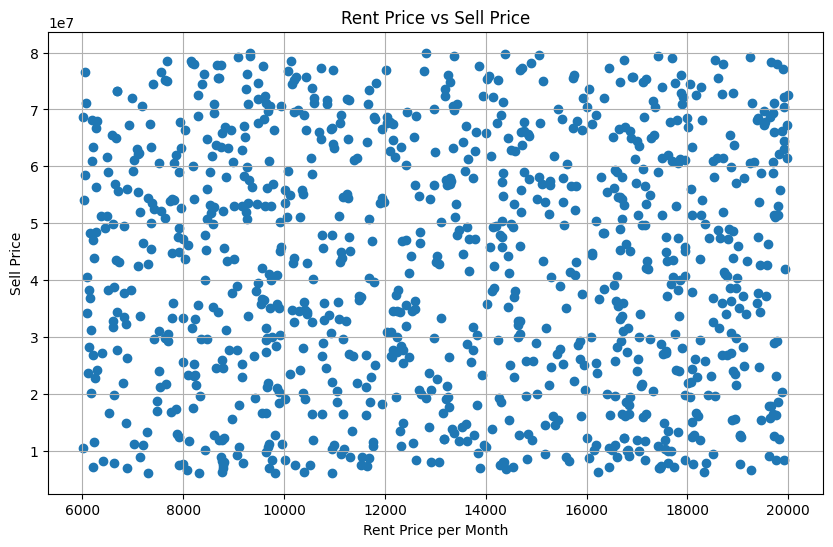

In [18]:
# 繪製散佈圖
plt.figure(figsize=(10, 6))
plt.scatter(data['Rent Price per Month'], data['Sell Price'])

# 設定標題和標籤
plt.title('Rent Price vs Sell Price')
plt.xlabel('Rent Price per Month')
plt.ylabel('Sell Price')

# 顯示網格
plt.grid(True)

# 顯示圖表
plt.show()